Loaded 1.12e+06 events (max 10000000)


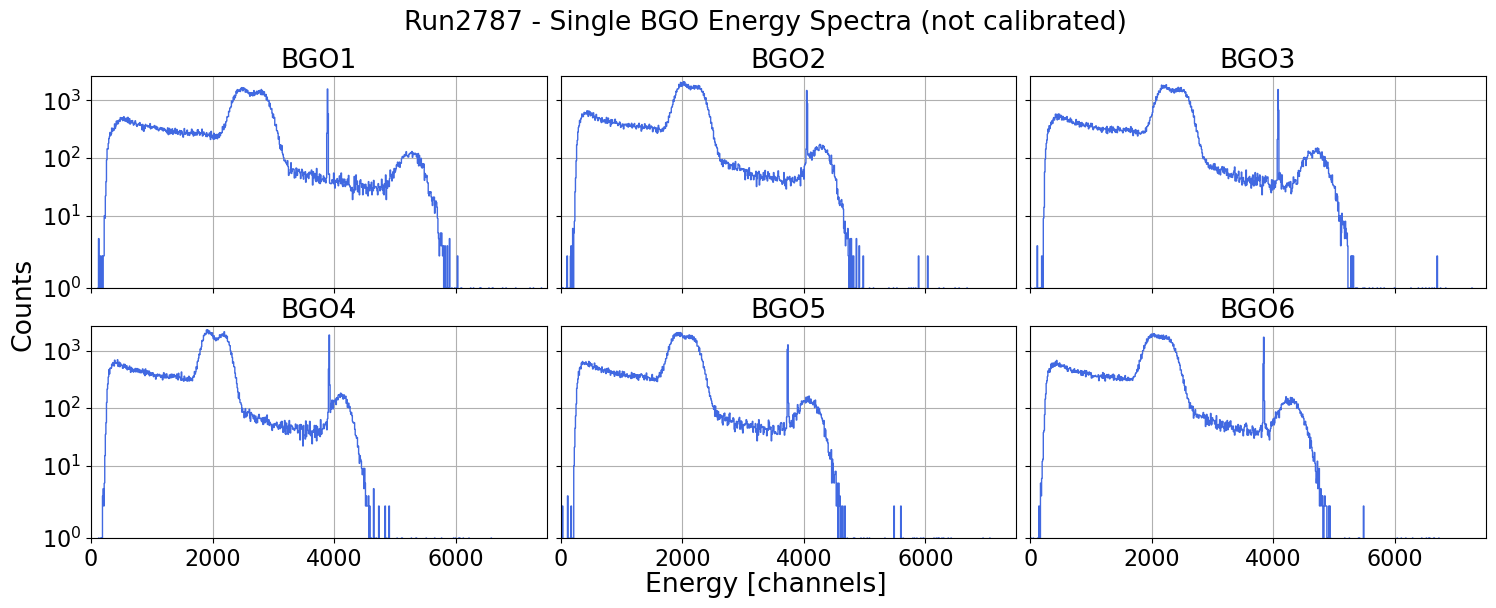

In [40]:
#======================#
#   Import Libraries   #
#======================#

import ROOT
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
import pandas as pd
from scipy.optimize import curve_fit

RUN = 2787

#==================#
#   Data Loading   #
#==================#

# limit number of events to load
nmax = int(1e7)

f = ROOT.TFile(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/ROOT/run{RUN}.root")
rdf = ROOT.RDataFrame("DataR", f).Range(nmax)  # take up to nmax entries
events = rdf.AsNumpy(columns=["Channel", "Energy"])

Channel = events["Channel"]
Energy = events["Energy"]

BGO1 = Energy[Channel == 1]
BGO2 = Energy[Channel == 2]
BGO3 = Energy[Channel == 3]
BGO4 = Energy[Channel == 4]
BGO5 = Energy[Channel == 5]
BGO6 = Energy[Channel == 6]
BGO = [BGO1, BGO2, BGO3, BGO4, BGO5, BGO6]

print(f"Loaded {len(Channel):.2e} events (max {nmax})")

#===================================#
#   Plotting Uncalibrated Spectra   #
#===================================#

fig, [[ax0,ax1,ax2],[ax3,ax4,ax5]] = plt.subplots(2, 3, figsize=(18,6), sharex=True, sharey=True)
axes = [ax0,ax1,ax2,ax3,ax4,ax5]

fig.suptitle(f"Run{RUN} - Single BGO Energy Spectra (not calibrated)", y=0.99)
fig.supxlabel("Energy [channels]", y=0.01)
fig.supylabel("Counts", x=0.08)
plt.yscale("symlog")

for i in range(6):
    axes[i].set_title(f"BGO{i+1}")
    axes[i].hist(BGO[i], bins=np.linspace(1, 7500, 800), histtype='step', label="BGO{}".format(i+1), color="royalblue")
    axes[i].set_xlim(0, 7500)
    axes[i].set_ylim(1, None)
    axes[i].grid()

plt.subplots_adjust(hspace=0.18, wspace=0.03)

plt.show()

2787,BGO6,1173.2,2006.6837243945795
2787,BGO6,1332.5,2250.7875841856944


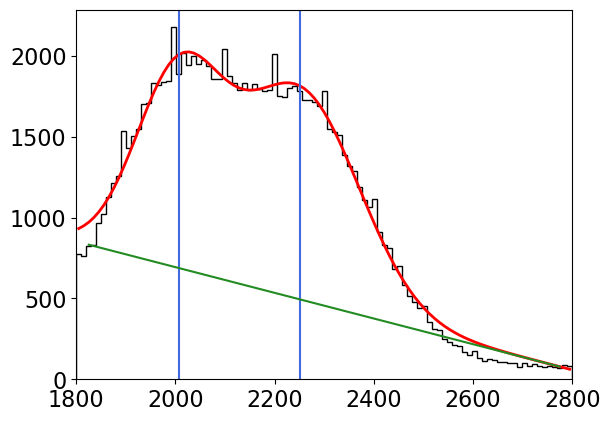

In [47]:
# Recover only the bins within ROI of BGO1

BGO_f = 6
if BGO_f == 1:
    ROI_min, ROI_max = 2000, 3200 # For BGO1
elif BGO_f == 6:
    ROI_min, ROI_max = 1800, 2800 # For BGO6
else:
    ROI_min, ROI_max = 1600, 2700 # For BGO2-5

BGO_index = BGO_f - 1

BGO_f = BGO[BGO_f-1]

def filter(roi_min, roi_max):
    return (BGO_f >= roi_min) & (BGO_f <= roi_max)

BGO1_filtered = BGO_f[filter(ROI_min, ROI_max)]

def double_gaussian(x, A1, mu1, sigma1, A2, mu2, sigma2):
    return (A1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) + 
            A2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2)) + 
            m * x + q)  # Add linear background


# Fit the BGO1_filtered histogram with a double Gaussian
# plt.yscale("symlog")
hist = plt.hist(BGO1_filtered, bins=np.linspace(ROI_min, ROI_max, 100), histtype='step', label="BGO1 Filtered", color="black")

# Covell method to remove linear background
X0, Y0 = (hist[1][:-1] + hist[1][1:]) / 2, hist[0]
X0, Y0 = X0[:5].mean(), Y0[:5].mean()
# print(X0, Y0)
X1, Y1 = (hist[1][:-1] + hist[1][1:]) / 2, hist[0]
X1, Y1 = X1[-5:].mean(), Y1[-5:].mean()
# print(X1, Y1)
m = (Y1 - Y0) / (X1 - X0)
q = Y0 - m * X0

# # Remove the linear background from the histogram
# hist = (hist[0] - (m * (hist[1][:-1] + hist[1][1:]) / 2 + q), hist[1])

popt, pcov = curve_fit(double_gaussian, (hist[1][:-1] + hist[1][1:]) / 2, hist[0], p0=[1000, ROI_min+400, 50, 1000, ROI_max-400, 20])
A1, mu1, sigma1, A2, mu2, sigma2 = popt

print(f"{RUN},BGO{BGO_index+1},1173.2,{mu1}")
print(f"{RUN},BGO{BGO_index+1},1332.5,{mu2}")

plt.plot((hist[1][:-1] + hist[1][1:]) / 2, double_gaussian((hist[1][:-1] + hist[1][1:]) / 2, *popt), label="Double Gaussian Fit", color="red", lw=2)
plt.axvline(mu1, color="royalblue")
plt.axvline(mu2, color="royalblue")
plt.plot([X0, X1], [Y0, Y1], color="forestgreen", label="Background")

plt.xlim(ROI_min, ROI_max)
plt.show()

2787,BGO1,2505.7,5269.82
2787,BGO2,2505.7,4268.62
2787,BGO3,2505.7,4719.16
2787,BGO4,2505.7,4118.44
2787,BGO5,2505.7,4093.41
2787,BGO6,2505.7,4293.65


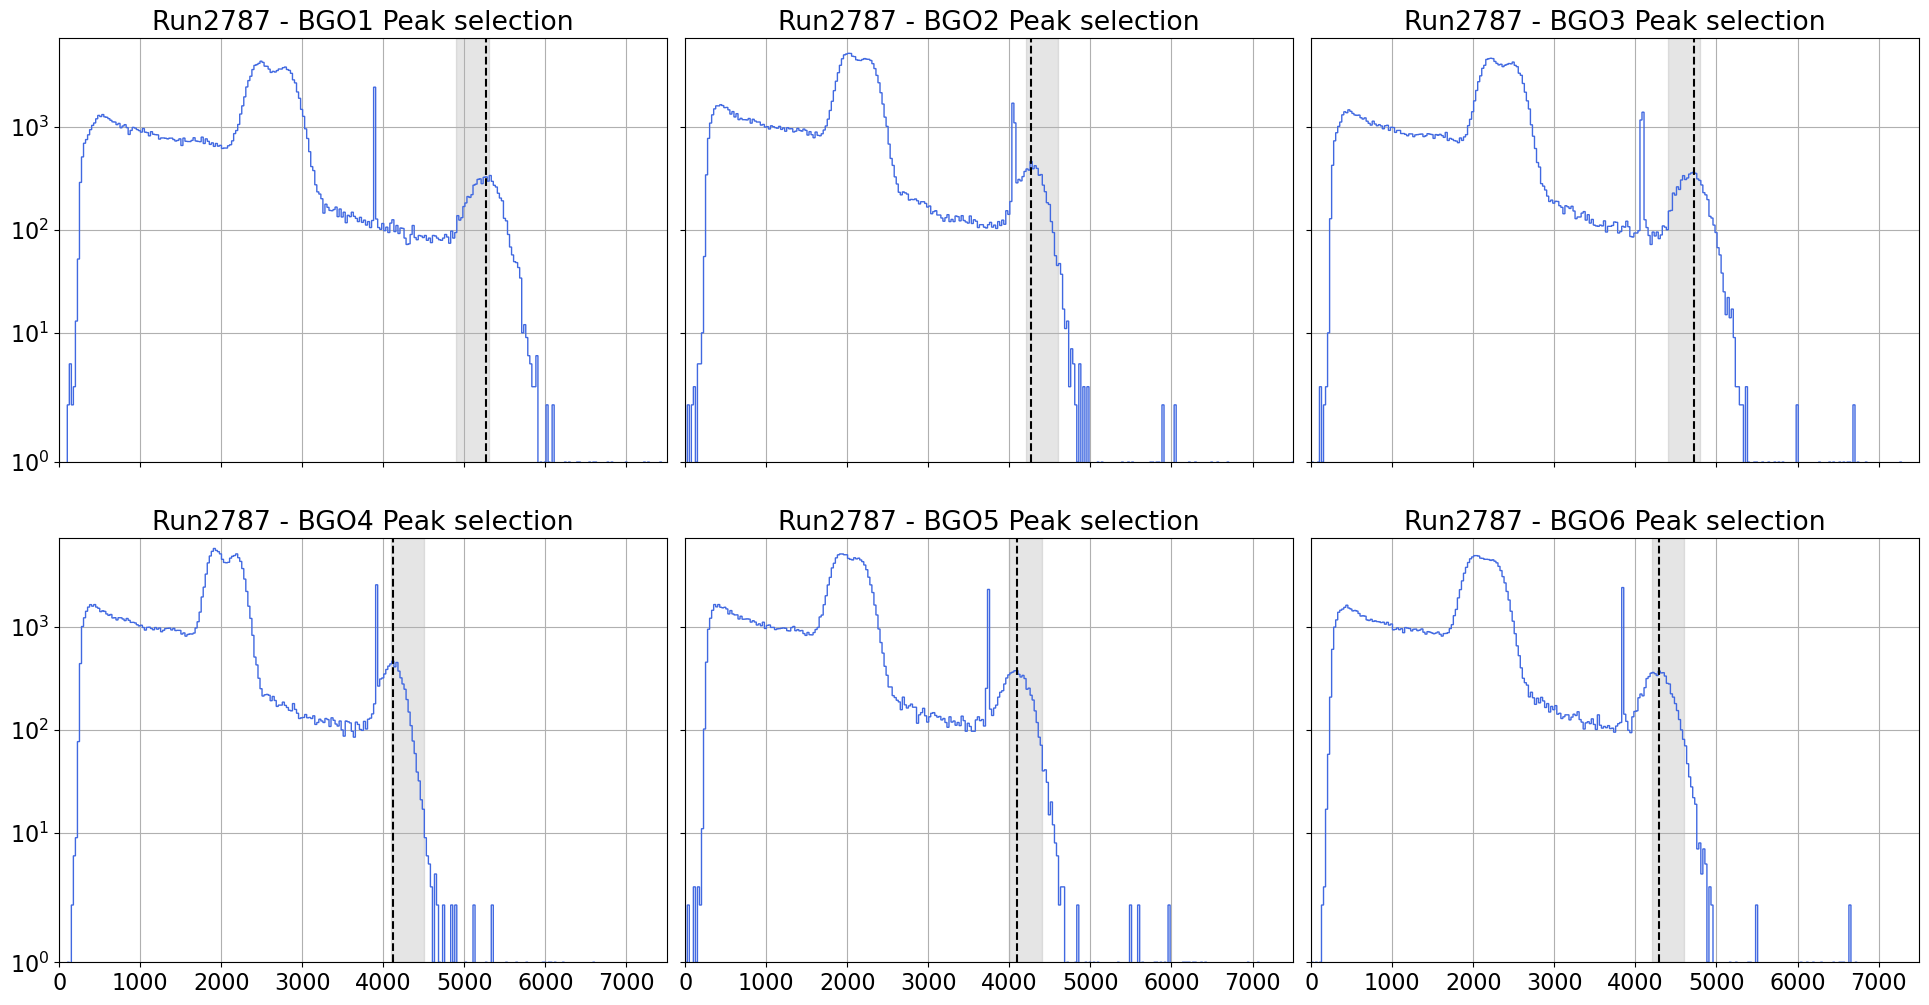

In [49]:
#=====================#
#   Peaks Selection   #
#=====================#

BGOs_focus = np.arange(1,7)

# ROI @340 Beamtime 2
# ROI_center = [
#     [400, 4500, 4900, 9200],
#     [400, 4600, 5150, 9600],
#     [400, 4100, 4500, 8800],
#     [400, 4300, 4700, 9000],
#     [400, 4500, 5000, 9600],
#     [400, 4700, 5300, 9500],
# ]

# ROI #240 Beamtime 2
# ROI_center = [
#     [400, 4600, 5100, 9000],
#     [400, 4600, 5150, 9000],
#     [400, 4150, 4700, 8600],
#     [400, 4300, 4700, 8600],
#     [400, 4500, 5000, 9100],
#     [400, 4900, 5300, 9300],
    # [400, 3800, 5150, 9000],
    # [400, 3800, 5150, 9100],
    # [400, 3500, 4700, 8700],
    # [400, 3500, 4700, 8700],
    # [400, 3600, 5000, 9200],
    # [600, 3800, 5300, 9200],
# ]

a = 5100 # Beamtime 3
base_values = np.array([a],float)

# Idx regions to be neglected
neglect = []

# ROI Beamtime 3
ROI_center = [
    # BGO1
    base_values,
    # BGO2
    base_values - np.array([700],float),
    # BGO3
    base_values - np.array([500],float),
    # BGO4
    base_values - np.array([800],float),
    # BGO5
    base_values - np.array([900],float),
    # BGO6
    base_values - np.array([700],float)
]

# # ROI Beamtime 4
# ROI_center = [
#     # BGO1
#     base_values,
#     # BGO2
#     base_values - np.array([100,700,1400,1400,1100,600],float),
#     # BGO3
#     base_values - np.array([100,500,700,600,525,500],float),
#     # BGO4
#     base_values - np.array([150,800,1300,1200,1000,800],float),
#     # BGO5
#     base_values - np.array([200,900,1400,1400,1000,800],float),
#     # BGO6
#     base_values - np.array([100,500,800,800,900,1000],float)
# ]

if len(neglect) > 0:
    neg = np.array(neglect, dtype=int)
    new_ROI_center = []
    for roi in ROI_center:
        mask = np.ones(roi.size, dtype=bool)
        valid = neg[neg < roi.size]
        if valid.size > 0:
            mask[valid] = False
        new_ROI_center.append(roi[mask])
    ROI_center = new_ROI_center

ROI_sigma = 200.0

Energies = np.array([1173.2+1332.5],float) # keV

# remove energies at indices in neglect (handles multiple indices)
if len(neglect) > 0:
    Energies = np.delete(Energies, neglect)

def gauss(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

def double_gauss(x, a1, x01, sigma1, a2, x02, sigma2):
    return (a1 * np.exp(-(x - x01)**2 / (2 * sigma1**2)) +
            a2 * np.exp(-(x - x02)**2 / (2 * sigma2**2)))

fig, axes = plt.subplots(2, 3, figsize=(24, 12), sharex=True, sharey=True)
axs = axes.flatten()

for i, BGO_focus in enumerate(BGOs_focus):
    ax = axs[i]
    ax.set_title(f"Run{RUN} - BGO{BGO_focus} Peak selection")
    ax.set_yscale("symlog")

    hist = ax.hist(BGO[BGO_focus - 1], bins=np.linspace(1, 20000, 800), histtype='step', lw=3, color="royalblue")
    bin_centers = (hist[1][:-1] + hist[1][1:]) / 2

    counts = hist[0]
    idx_start = np.searchsorted(bin_centers, 15000, side='right')
    cut_val = 20000
    # require a consecutive window of 20 bins whose mean count < 1
    if idx_start <= len(counts) - 20:
        for i in range(idx_start, len(counts) - 19):
            if counts[i:i+20].mean() < 1:
                cut_val = bin_centers[i]
                break

    for idx, center in enumerate(ROI_center[BGO_focus-1]):
        mask = (bin_centers >= center - ROI_sigma) & (bin_centers <= center + ROI_sigma)
        xdata = bin_centers[mask]
        ydata = hist[0][mask]

        ax.axvspan(center - ROI_sigma, center + ROI_sigma, color='grey', alpha=0.2)

        try:
            # print(xdata.size, ydata.size)
            if xdata.size == 0 or ydata.size == 0:
                # Empty ROI: mark center as peak, plot line and print, then skip fitting
                x0 = center
                ax.axvline(x0, color="black", linestyle='--')
                print(f"{RUN},BGO{BGO_focus},{Energies[idx]},{x0:.2f}")
                continue
            # print(idx)
            if idx == 0:
                p0 = [ydata.max()/2, center-250, 100, ydata.max()/2, center+250, 100]
                popt, pcov = curve_fit(double_gauss, xdata, ydata, p0=p0, method='trf')
                amp1, x01, sigma1, amp2, x02, sigma2 = popt
                if amp1 <= 0 or sigma1 <= 0 or amp2 <= 0 or sigma2 <= 0 or not (center - ROI_sigma <= x01 <= center + ROI_sigma) or not (center - ROI_sigma <= x02 <= center + ROI_sigma) or sigma1 > ROI_sigma * 3 or sigma2 > ROI_sigma * 3:
                    raise ValueError("Unreasonable fit result")
            elif idx == 1:
                p0 = [ydata.max(), center, 60]
                popt, pcov = curve_fit(gauss, xdata, ydata, p0=p0, method='trf')
                amp, x0, sigma = popt
                if amp <= 0 or sigma <= 0 or not (center - ROI_sigma <= x0 <= center + ROI_sigma) or sigma > ROI_sigma * 3:
                    raise ValueError("Unreasonable fit result")

            x_fit = np.linspace(center - ROI_sigma, center + ROI_sigma, 1000)
            y_fit = gauss(x_fit, *popt)
            ax.plot(x_fit, y_fit, color="deeppink")
            err = np.sqrt(pcov[1,1]) if pcov is not None else np.nan
            ax.axvline(x0, color="black", ls="--")

        except Exception:
            x0 = xdata[np.argmax(ydata)]
            ax.axvline(x0, color="black", linestyle='--')

        energy = Energies[idx] if idx < Energies.size else None
        if energy is not None:
            print(f"{RUN},BGO{BGO_focus},{energy},{x0:.2f}")

    ax.set_xlim(0, 7500)
    ax.set_ylim(1, None)
    ax.grid()

plt.subplots_adjust(hspace=0.18, wspace=0.03)

plt.show()

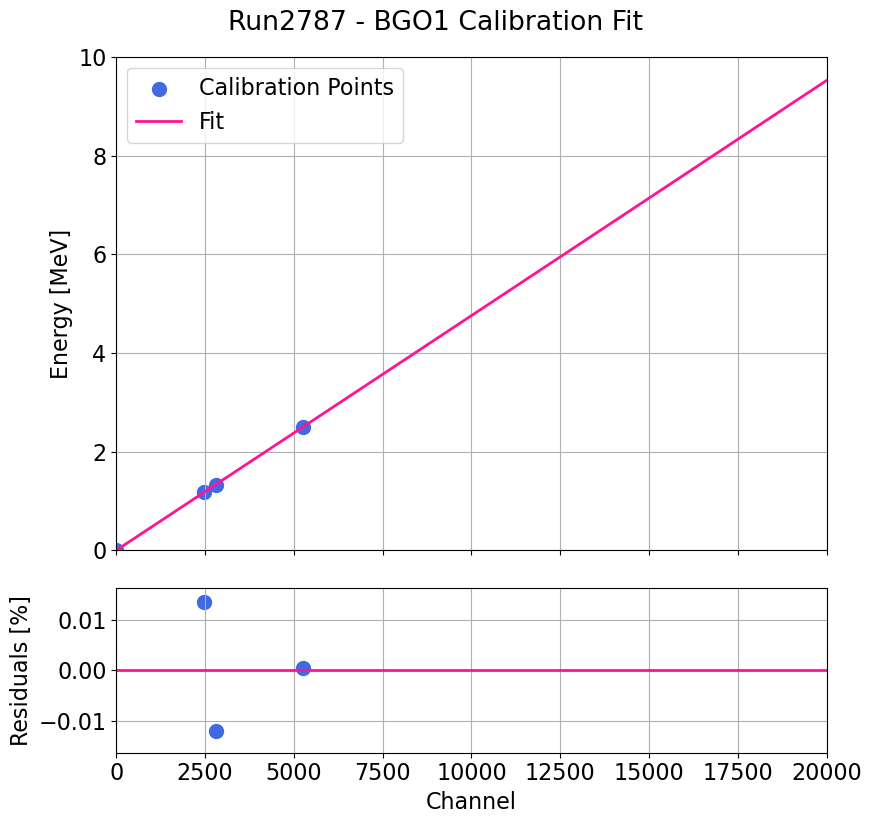

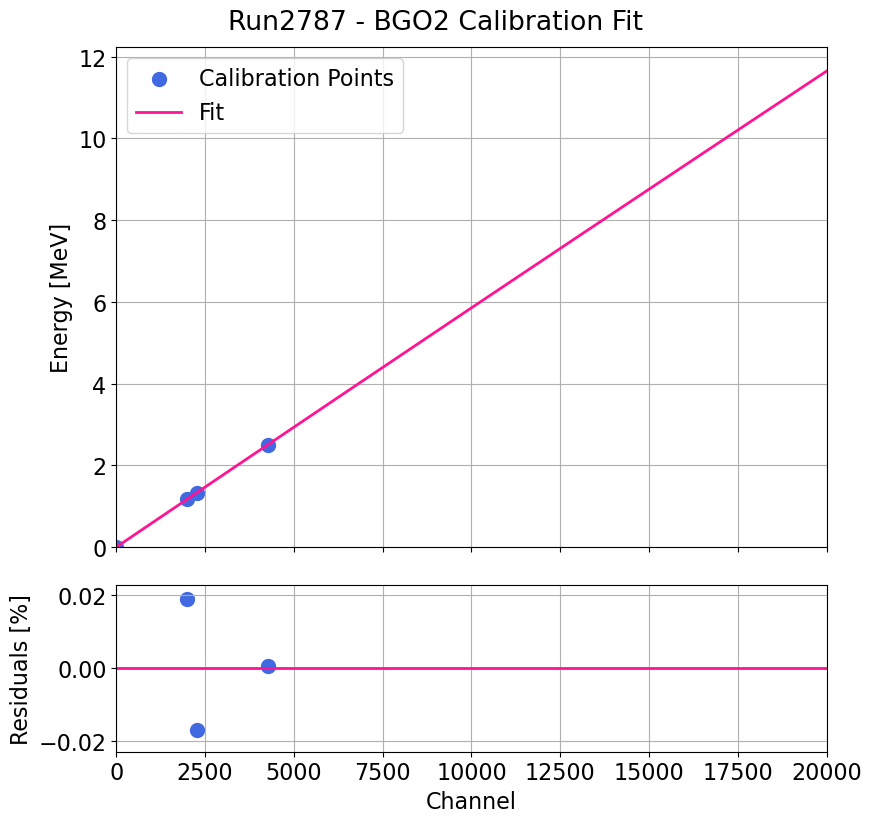

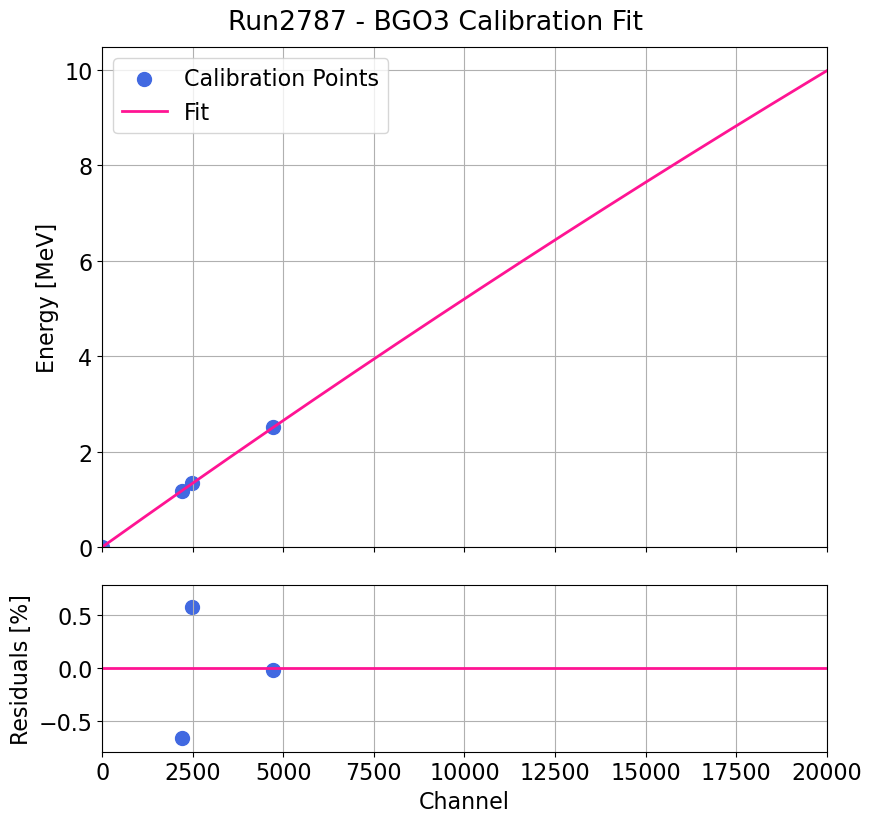

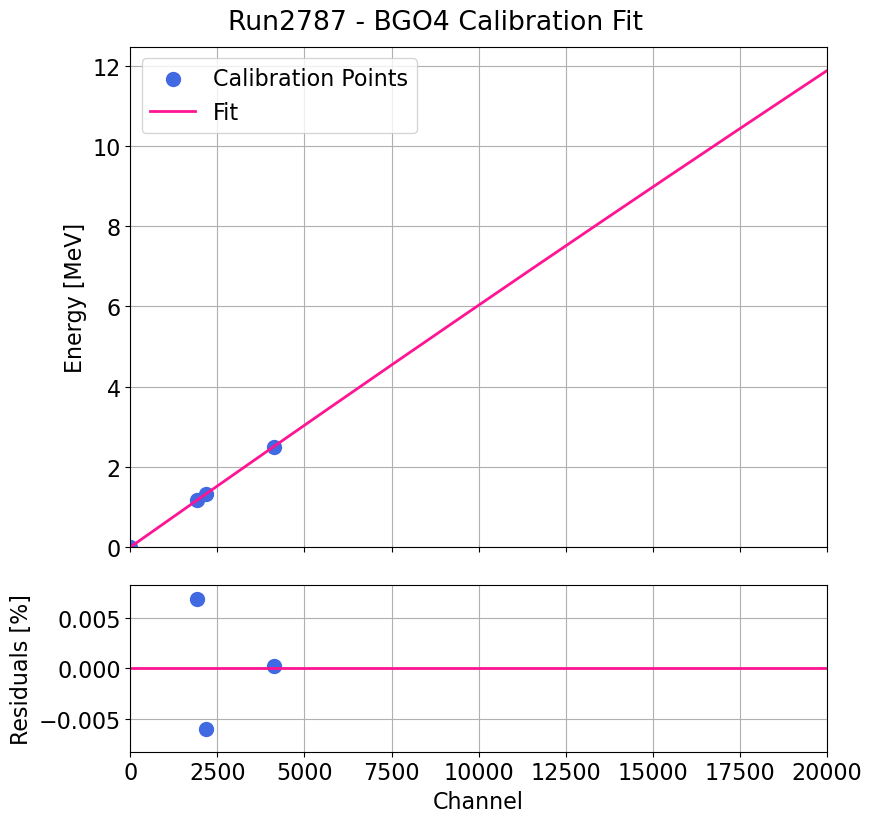

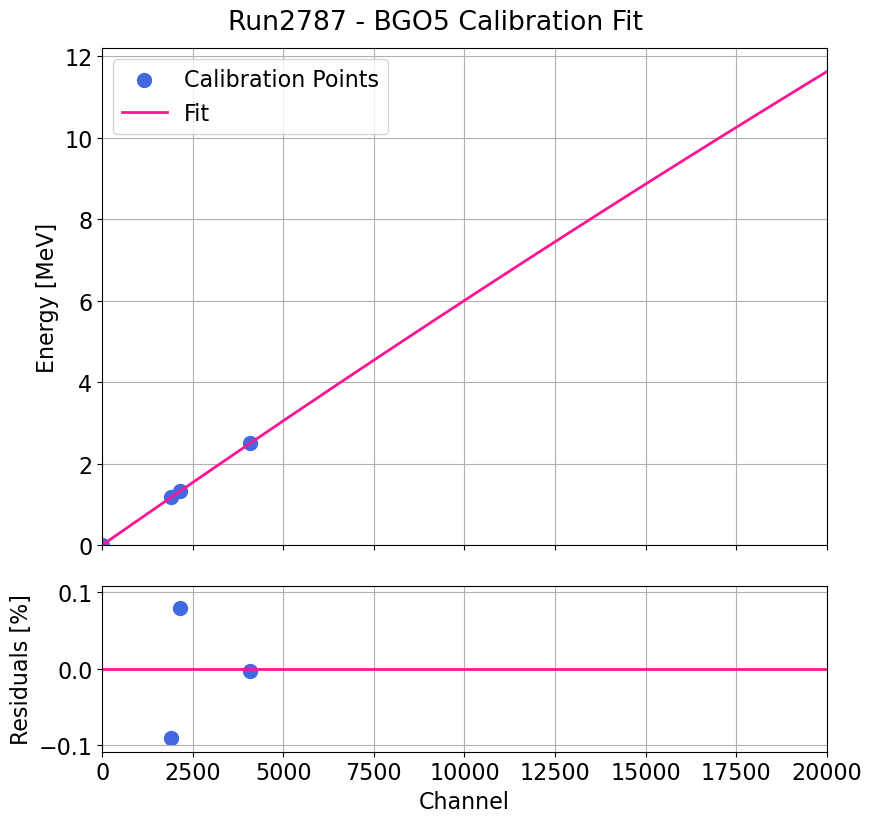

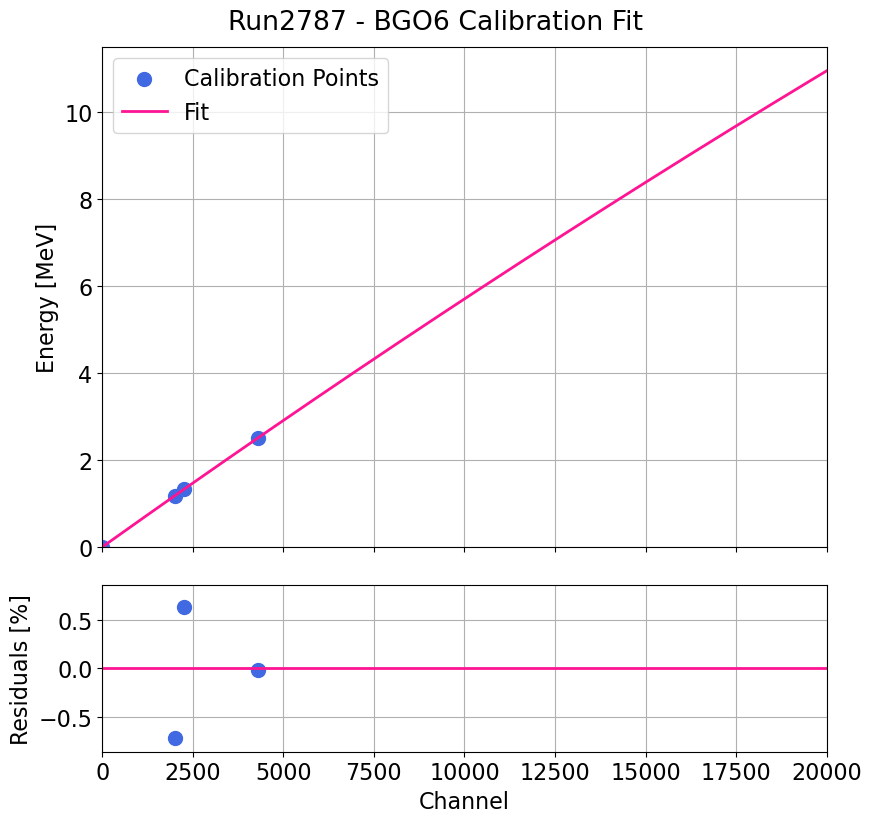

In [50]:
#=====================#
#   Calibration Fit   #
#=====================#

# BGO_cuts = [np.float64(17309.27096370463), np.float64(16333.099499374217), np.float64(17184.12077596996), np.float64(16458.249687108888), np.float64(16633.459949937424), np.float64(16533.339799749687)]


def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

def cubic(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

def fourth_order(x, a, b, c, d, e):
    return a * x**4 + b * x**3 + c * x**2 + d * x + e

df = pd.read_csv("/data0/biasissi/LUNA/19F+p_g+20Ne/Calibration/calibration_lines_sources.csv", delimiter=",")
df = df[df["Run"] == RUN]

params = []

for BGO in range(1,7):
    df_BGO = df[df["BGO"] == f"BGO{BGO}"]

    # original calibration points (Energy in MeV)
    Energy = (df_BGO["Energy"].values / 1e3)
    Channel = df_BGO["Channel"].values

    # add the (0,0) calibration point
    Channel = np.concatenate(([0], Channel))
    Energy = np.concatenate(([0], Energy))

    # # add the (BGO_cut, 14500) calibration point
    # Channel = np.concatenate(([BGO_cuts[BGO-1]], Channel))
    # Energy = np.concatenate(([17.5], Energy))
    

    # fit cubic to the augmented arrays
    popt, pcov = curve_fit(quadratic, Channel, Energy)

    # store parameters in keV units (consistent with previous behavior)
    params.append(popt * 1e3)

    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(9,9),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

    fig.suptitle(f"Run{RUN} - BGO{BGO} Calibration Fit", y=0.92)

    # Top: calibration points (including (0,0)) and cubic fit
    ax0.scatter(Channel, Energy, color='royalblue', label='Calibration Points', s=100)
    x_fit = np.linspace(0, 20000, 1000)
    y_fit = quadratic(x_fit, *popt)
    ax0.plot(x_fit, y_fit, color='deeppink', label='Fit', lw=2)

    ax0.set_ylabel("Energy [MeV]")
    ax0.set_xlim(0, 20000)
    ax0.set_ylim(0, None)
    ax0.grid()
    ax0.legend()

    # Bottom: relative residuals computed only on original points (exclude the artificial 0,0 to avoid div-by-zero)
    mask = Energy != 0
    if mask.sum() == 0:
        resid = np.zeros_like(Energy)
    else:
        resid = (Energy[mask] - quadratic(Channel[mask], *popt)) / Energy[mask] * 100
    ax1.scatter(Channel[mask], resid, color='royalblue', s=100)
    ax1.axhline(0, color='deeppink', lw=2)

    if resid.size:
        ax1.set_ylim(-np.max(np.abs(resid)) * 1.2, np.max(np.abs(resid)) * 1.2)
    else:
        ax1.set_ylim(-1, 1)

    ax1.set_xlabel("Channel")
    ax1.set_ylabel("Residuals [%]")

    ax1.grid()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

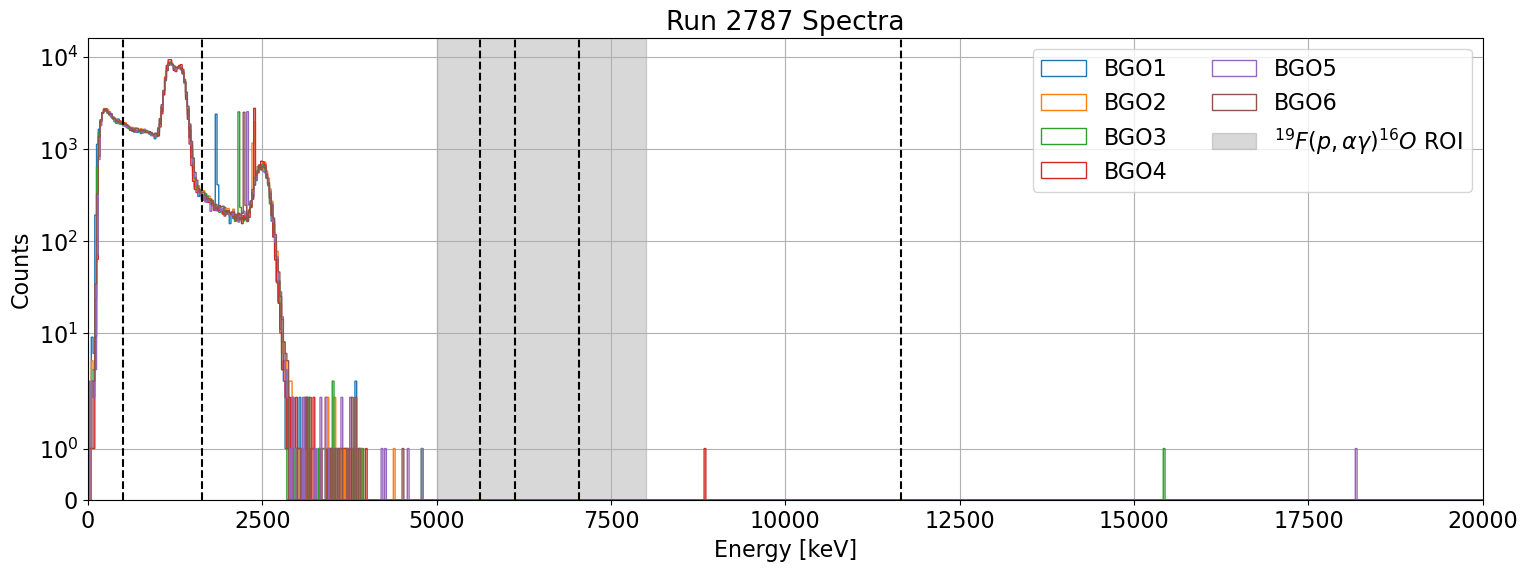

In [51]:
#==================#
#   Data Loading   #
#==================#

# limit number of events to load
nmax = int(1e7)

f = ROOT.TFile(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/ROOT/run{RUN}.root")
rdf = ROOT.RDataFrame("DataR", f).Range(nmax)  # take up to nmax entries
events = rdf.AsNumpy(columns=["Channel", "Energy"])

Channel = events["Channel"]
Energy = events["Energy"]

BGO1 = Energy[Channel == 1]
BGO2 = Energy[Channel == 2]
BGO3 = Energy[Channel == 3]
BGO4 = Energy[Channel == 4]
BGO5 = Energy[Channel == 5]
BGO6 = Energy[Channel == 6]
BGO = [BGO1, BGO2, BGO3, BGO4, BGO5, BGO6]

# # read rows 1..6 (skip the first header line) and keep only the parameter columns
# popts = np.genfromtxt(f"Params/calibration_run{RUN}.txt", dtype=float, delimiter=None, skip_header=1, max_rows=6)
# # drop the leading index column (first column)
# if popts.ndim == 1:
#     popts = popts[1:]
# else:
#     popts = popts[:, 1:]

# # Reverse each row
# popts = popts[:, ::-1]

#=================================================#
#   Plot Single Crystals & Sum Spectrum Spectra   #
#=================================================#

plt.figure(figsize=(18, 6))

plt.title(f'Run {RUN} Spectra')

plt.yscale('symlog')

# plt.hist(events["energySum"], bins=np.linspace(1, 20000, 1200), histtype='step', color='deeppink', linewidth = 2, label='Sum Spectrum')

for i in range(6):
    plt.hist(quadratic(BGO[i], *params[i]), bins=np.linspace(1, 20000, 800), histtype='step', label="BGO{}".format(i+1))
    
    # hist(events[f"energyBGO{i+1}"], bins=np.linspace(1, 20000, 1200), histtype='step', label=f'BGO {i+1}')

plt.axvline(6128, color='black', ls='--')
plt.axvline(6128-511, color='black', ls='--')
plt.axvline(7050, color='black', ls='--')
plt.axvline(1633, color='black', ls='--')
plt.axvline(511, color='black', ls='--')
plt.axvline(11660, color='black', ls='--')
plt.axvspan(5000,8000, color='gray', alpha=0.3, label=r'${}^{19}F(p,\alpha\gamma){}^{16}O$ ROI')

plt.xlabel('Energy [keV]')
plt.ylabel('Counts')

plt.xlim(0, 20000)
plt.ylim(0, None)

plt.grid()
plt.legend(loc='upper right', ncols=2)

plt.show()

In [52]:
#===================================#
#   Generate the Calibration File   #
#===================================#

out_fname = f"Params/calibration_run{RUN}.txt"
with open(out_fname, "w") as f:
    f.write("0	0	1\n")
    for i, p in enumerate(params, start=1):
        # write params in opposite order (c,b,a) for quadratic a*x^2 + b*x + c
        f.write(f"{i}\t" + "\t".join(map(str, p[::-1])) + "\n")
    f.write("7	0	1")
print(f"Calibration file written: {out_fname}")

Calibration file written: Params/calibration_run2787.txt


Run2165 - Total: 4566721, Background: 624847, Net: 3941874
0.5455138347871604
Run2789 - Total: 4592004, Background: 651557, Net: 3940447
0.5285075646028514


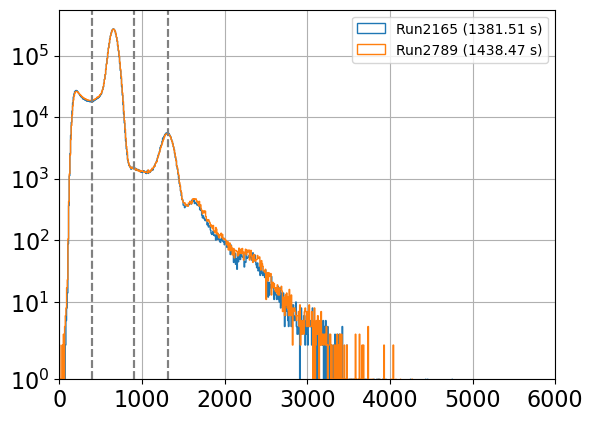

In [85]:
# For 60Co
RUNs = [2164, 2787]
times = [1654.01, 242.57] # in seconds
activity = [2.67879204265625*1e3, 2.36315644464623*1e3] # in Bq, corrected for decay to the time of measurement

# For 137Cs
RUNs = [2165, 2789]
times = [1381.51, 1438.47]
activity = [5.23049708994054*1e3, 5.18314585016348*1e3]



# fig, axes = plt.subplots(2, 3, figsize=(18,6), sharex=True, sharey=True)
# axes = axes.flatten()
bins = np.linspace(1, 6000, 750)

def integrate_with_linear_bg(data, roi_low, roi_high, bg_left, bg_right, bins):
    hist, bin_edges = np.histogram(data, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Background regions
    left_mask = (bin_centers >= bg_left[0]) & (bin_centers <= bg_left[1])
    right_mask = (bin_centers >= bg_right[0]) & (bin_centers <= bg_right[1])
    
    # Estimate linear background from left and right regions
    left_mean_x = bin_centers[left_mask].mean()
    left_mean_y = hist[left_mask].mean()
    right_mean_x = bin_centers[right_mask].mean()
    right_mean_y = hist[right_mask].mean()
    
    slope = (right_mean_y - left_mean_y) / (right_mean_x - left_mean_x)
    intercept = left_mean_y - slope * left_mean_x
    
    # ROI
    roi_mask = (bin_centers >= roi_low) & (bin_centers <= roi_high)
    roi_centers = bin_centers[roi_mask]
    roi_counts = hist[roi_mask]
    
    # Subtract background
    bg_counts = slope * roi_centers + intercept
    net_counts = roi_counts - bg_counts
    
    total_counts = roi_counts.sum()
    bg_total = bg_counts.sum()
    net_total = net_counts.sum()
    
    return total_counts, bg_total, net_total

for RUN in RUNs:
    f = ROOT.TFile(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/PROCESSED/run{RUN}.root")
    df = ROOT.RDataFrame("coincidenceEvents", f)
    events = df.AsNumpy(columns=["energyBGO1", "energyBGO2", "energyBGO3", "energyBGO4", "energyBGO5", "energyBGO6", "energySum"])
    BGO = [events[f"energyBGO{i+1}"] for i in range(6)]
    BGO_sum = events["energySum"]

    plt.yscale("symlog")
    plt.hist(BGO_sum, bins=bins, histtype='step', label=f"Run{RUN} ({round(times[RUNs.index(RUN)],2)} s)", lw=1.5)
    plt.xlim(0, 6000)
    plt.ylim(1, None)
    plt.legend(loc='upper right', fontsize=10)
    plt.axvline(400, color="grey", ls="--")
    plt.axvline(900, color="grey", ls="--")
    plt.axvline(661*2, color="grey", ls="--")

    # total, bg, net = integrate_with_linear_bg(BGO_sum, roi_low=2100, roi_high=3000, bg_left=(2000,2100), bg_right=(3000,3100), bins=bins)
    total, bg, net = integrate_with_linear_bg(BGO_sum, roi_low=400, roi_high=900, bg_left=(350,400), bg_right=(900,1000), bins=bins)


    print(f"Run{RUN} - Total: {total:.0f}, Background: {bg:.0f}, Net: {net:.0f}")
    print(net / times[RUNs.index(RUN)] / activity[RUNs.index(RUN)]) # in ppm

    

    

    # hist = [np.histogram(BGO[i], bins=bins)[0] for i in range(6)]


    # for i in range(6):
    #     axes[i].set_title(f"BGO{i+1}")
    #     axes[i].set_yscale("symlog")
    #     axes[i].set_title(f"BGO{i+1}")
    #     axes[i].hist(BGO[i], bins=bins, histtype='step', label=f"Run{RUN} ({times[RUNs.index(RUN)]} seconds)", lw=1.5)
    #     axes[i].set_xlim(0, 6000)
    #     axes[i].set_ylim(1, None)
    #     axes[i].grid()
    #     axes[i].legend(loc='upper right', fontsize=10)

    #     axes[i].axvline(4500, color="grey", ls="--")
    #     axes[i].axvline(6000, color="grey", ls="--")
# fig.suptitle(f"Comparison Run{RUN} vs Run{RUN2} - Single BGO Energy Spectra", y=0.99)
fig.supxlabel("Energy [channels]", y=0.01)
fig.supylabel("Counts", x=0.08)
plt.subplots_adjust(hspace=0.18, wspace=0.03)
plt.grid()
# plt.savefig(f"Run{RUN}_vs_Run{RUN2}_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [33]:
# Integrate a region of BGO1 for runs 2164 and 2787 comprised between 2000 and 3000 removing a linear background estimated from the region between 1800-2000 and 3000-3200

def integrate_with_linear_bg(data, roi_low, roi_high, bg_left, bg_right, bins):
    hist, bin_edges = np.histogram(data, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Background regions
    left_mask = (bin_centers >= bg_left[0]) & (bin_centers <= bg_left[1])
    right_mask = (bin_centers >= bg_right[0]) & (bin_centers <= bg_right[1])
    
    # Estimate linear background from left and right regions
    left_mean_x = bin_centers[left_mask].mean()
    left_mean_y = hist[left_mask].mean()
    right_mean_x = bin_centers[right_mask].mean()
    right_mean_y = hist[right_mask].mean()
    
    slope = (right_mean_y - left_mean_y) / (right_mean_x - left_mean_x)
    intercept = left_mean_y - slope * left_mean_x
    
    # ROI
    roi_mask = (bin_centers >= roi_low) & (bin_centers <= roi_high)
    roi_centers = bin_centers[roi_mask]
    roi_counts = hist[roi_mask]
    
    # Subtract background
    bg_counts = slope * roi_centers + intercept
    net_counts = roi_counts - bg_counts
    
    total_counts = roi_counts.sum()
    bg_total = bg_counts.sum()
    net_total = net_counts.sum()
    
    return total_counts, bg_total, net_total

bins = np.linspace(1, 7500, 800)
roi_low, roi_high = 4500, 6000
bg_left, bg_right = (4300,4500), (6000, 6200)

# Run 2164
total_2164, bg_2164, net_2164 = integrate_with_linear_bg(BGO[0], roi_low, roi_high, bg_left, bg_right, bins)

# Run 2787
total_2787, bg_2787, net_2787 = integrate_with_linear_bg(BGO_run2[0], roi_low, roi_high, bg_left, bg_right, bins)

print(f"Run {RUN} BGO1: Total={total_2164:.0f}, Background={bg_2164:.0f}, Net={net_2164:.0f}, Percentage of Net={net_2164/total_2164*100:.2f}%")
print(f"Run {RUN2} BGO1: Total={total_2787:.0f}, Background={bg_2787:.0f}, Net={net_2787:.0f}, Percentage of Net={net_2787/total_2787*100:.2f}%")


Run 2164 BGO1: Total=55408, Background=19368, Net=36040, Percentage of Net=65.05%
Run 2787 BGO1: Total=7625, Background=2625, Net=5000, Percentage of Net=65.58%


In [74]:
# Recover the current file
def time_recover(RUN):
    timestamp = np.genfromtxt("/data0/biasissi/LUNA/19F+p_g+20Ne/Data/CURRENT/run{}.txt".format(RUN), usecols=(0), unpack=True)

    print(timestamp[0], timestamp[-1])
    delta = timestamp[-1] - timestamp[0]
    print(f"Run{RUN} duration: {delta:.2f} seconds")
    return delta

delta_2164 = time_recover(2164)
delta_2787 = time_recover(2787)
delta_2165 = time_recover(2165)
delta_2789 = time_recover(2789)

# activity_2164 = 2.67879204265625*1e3
# activity_2787 = 2.36315644464623*1e3


# print(net_2164/(delta_2164*activity_2164))
# print(net_2787/(delta_2787*activity_2787))

0.388320208 1654.39831
Run2164 duration: 1654.01 seconds
0.655001163 243.229631
Run2787 duration: 242.57 seconds
0.201501131 1381.71368
Run2165 duration: 1381.51 seconds
0.450692892 1438.92442
Run2789 duration: 1438.47 seconds
